# Topology: rho, lambda, alpha

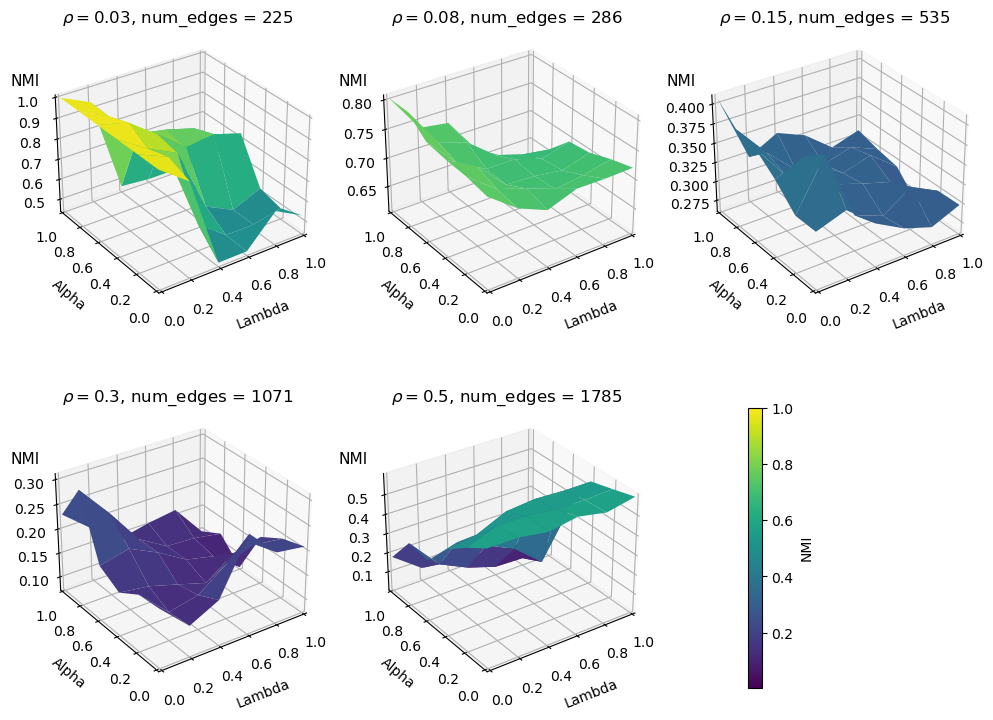

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# ------------------------------------------------------------------
# Leitura dos dados
# ------------------------------------------------------------------
df = pd.read_csv(
    "/home/gui-messias/Desktop/pip_synthetic_graphgen/synthetic_graphgen/experiments/results/topologic/topology_rho_2026_02_25_15_15_07/metrics/results.csv"
)

df = df.sort_values(['rho', 'lambda', 'alpha'])

rhos = sorted(df["rho"].unique())

# ------------------------------------------------------------------
# Figura 2x3
# ------------------------------------------------------------------
fig = plt.figure(figsize=(10, 7))

# Normalização GLOBAL da cor
norm = plt.Normalize(df["nmi"].min(), df["nmi"].max())

# Ângulo de visualização (AJUSTE AQUI)
ELEV = 30   # inclinação
AZIM = 235  # rotação horizontal

# Posições dos gráficos (ignorando [2,3])
positions = [1, 2, 3, 4, 5]

# ------------------------------------------------------------------
# Loop pelos valores de rho
# ------------------------------------------------------------------
for pos, rho in zip(positions, rhos):
    ax = fig.add_subplot(2, 3, pos, projection='3d')

    df_rho = df[df["rho"] == rho]

    pivot = df_rho.pivot_table(
        index='lambda',
        columns='alpha',
        values='nmi',
        aggfunc='mean'
    )

    lambda_vals = pivot.index.values
    alpha_vals = pivot.columns.values

    Lambda, Alpha = np.meshgrid(lambda_vals, alpha_vals)
    Z = pivot.values.T

    surf = ax.plot_surface(
        Lambda,
        Alpha,
        Z,
        cmap=cm.viridis,
        norm=norm,
        edgecolor='none',
        antialiased=True
    )

    # Ângulo de visualização
    ax.view_init(elev=ELEV, azim=AZIM)

    # Título mais próximo do gráfico
    vl = df_rho["num_edges_generated"].iloc[0]
    ax.set_title(f"$\\rho = {rho}$, num_edges = {int(vl/2)}", pad=0)

    ax.set_xlabel('Lambda', labelpad=6)
    ax.set_ylabel('Alpha', labelpad=6)
    ax.set_zlabel('NMI', labelpad=6)
    ax.set_zlabel("")  # remove o padrão

    ax.text2D(
        -0.1, 0.8,
        "NMI",
        transform=ax.transAxes,
        fontsize=11,
        # weight="bold"
    )

    ax.set_xlim(0, lambda_vals.max())
    ax.set_ylim(0, alpha_vals.max())

# ------------------------------------------------------------------
# Subplot [2,3] reservado para a legenda
# ------------------------------------------------------------------
cax = fig.add_subplot(2, 3, 6)
cax.axis('off')

sm = cm.ScalarMappable(norm=norm, cmap=cm.viridis)
sm.set_array([])

fig.colorbar(
    sm,
    ax=cax,
    fraction=0.8,
    aspect=20,
    label='NMI'
)

plt.tight_layout()
plt.subplots_adjust(hspace=0.35)
plt.savefig("/home/gui-messias/Desktop/pip_synthetic_graphgen/synthetic_graphgen/experiments/results/figures/figura_nmi_surfaces.svg", format="svg", bbox_inches="tight")
plt.show()
plt.show()


# SFAnalysis

In [55]:
import sys

sys.path.append("")
import pandas as pd

df3 = pd.read_csv("results/sfanalysis/sfanalysis_2026_02_24_08_59_56_058611/metrics/results.csv")
df2 = pd.read_csv("results/sfanalysis/sfanalysis_2026_02_24_09_01_15_397939/metrics/results.csv")
df1 = pd.read_csv("results/sfanalysis/sfanalysis_2026_02_24_09_02_13_150165/metrics/results.csv")

In [60]:
df3

,alpha_3,n_tail_3,D_3,distribution_class_3,subgraph_3,model_3
0,2.546593,152.0,0.049953,Strong Scale-Free,0,SCAtt
1,2.744409,74.0,0.032750,Strong Scale-Free,1,SCAtt
2,2.985982,110.0,0.050339,Strong Scale-Free,2,SCAtt
3,3.285052,150.0,0.048292,Weak Scale-Free,3,SCAtt
4,9.525407,9.0,0.049648,Weak Scale-Free,4,SCAtt
5,3.870314,66.0,0.070146,Weak Scale-Free,5,SCAtt
6,4.005301,36.0,0.029730,Weak Scale-Free,6,SCAtt
7,2.276529,130.0,0.023133,Strong Scale-Free,0,GenCAT
8,2.109229,30.0,0.064323,Weak Scale-Free,1,GenCAT
9,2.284590,240.0,0.042644,Strong Scale-Free,2,GenCAT


In [56]:
print(df1.columns)

Index(['alpha', 'n_tail', 'D', 'distribution_class', 'subgraph', 'model'], dtype='object')


In [57]:
df2.columns = ["alpha_2", "n_tail_2", "D_2", "distribution_class_2", "subgraph_2", "model_2"]
df3.columns = ["alpha_3", "n_tail_3", "D_3", "distribution_class_3", "subgraph_3", "model_3"]
df = pd.concat([df1,df2,df3], axis = 1).round(2)

In [58]:
df = df.drop(columns=[
    "subgraph_2", "model_2",
    "subgraph_3", "model_3"
])

In [59]:
df

,alpha,n_tail,D,distribution_class,subgraph,model,alpha_2,n_tail_2,D_2,distribution_class_2,alpha_3,n_tail_3,D_3,distribution_class_3
0,2.77,103.0,0.04,Strong Scale-Free,0,SCAtt,2.60,237.0,0.03,Strong Scale-Free,2.55,152.0,0.05,Strong Scale-Free
1,2.98,69.0,0.05,Strong Scale-Free,1,SCAtt,2.92,55.0,0.04,Strong Scale-Free,2.74,74.0,0.03,Strong Scale-Free
2,3.37,106.0,0.05,Weak Scale-Free,2,SCAtt,3.45,60.0,0.02,Weak Scale-Free,2.99,110.0,0.05,Strong Scale-Free
3,3.23,206.0,0.04,Weak Scale-Free,3,SCAtt,3.26,147.0,0.03,Weak Scale-Free,3.29,150.0,0.05,Weak Scale-Free
4,2.85,249.0,0.03,Strong Scale-Free,4,SCAtt,4.56,42.0,0.04,Weak Scale-Free,9.53,9.0,0.05,Weak Scale-Free
5,4.41,33.0,0.04,Weak Scale-Free,5,SCAtt,6.00,17.0,0.03,Weak Scale-Free,3.87,66.0,0.07,Weak Scale-Free
6,3.42,65.0,0.03,Weak Scale-Free,6,SCAtt,3.56,31.0,0.03,Weak Scale-Free,4.01,36.0,0.03,Weak Scale-Free
7,2.07,363.0,0.04,Strong Scale-Free,0,GenCAT,1.96,102.0,0.02,Weak Scale-Free,2.28,130.0,0.02,Strong Scale-Free
8,2.06,190.0,0.04,Strong Scale-Free,1,GenCAT,2.04,172.0,0.03,Strong Scale-Free,2.11,30.0,0.06,Weak Scale-Free
9,2.02,249.0,0.03,Strong Scale-Free,2,GenCAT,2.03,309.0,0.02,Strong Scale-Free,2.28,240.0,0.04,Strong Scale-Free


In [51]:
import pandas as pd

vars_group = ["alpha", "n_tail", "D", "distribution_class"]

new_cols = []
for col in df.columns:
    if col in vars_group:
        new_cols.append((col, "1"))
    elif any(col == f"{v}_2" for v in vars_group):
        new_cols.append((col[:-2], "2"))
    elif any(col == f"{v}_3" for v in vars_group):
        new_cols.append((col[:-2], "3"))
    else:
        # mantém subgraph e model normais (sem multicol)
        new_cols.append((col, ""))

df2 = df.copy()
df2.columns = pd.MultiIndex.from_tuples(new_cols)

ordered = []

for v in vars_group:
    for r in ["1", "2", "3"]:
        if (v, r) in df2.columns:
            ordered.append((v, r))

# adiciona subgraph e model no final
ordered += [c for c in df2.columns if c[0] not in vars_group]

df2 = df2.loc[:, ordered]

for r in ["1", "2", "3"]:
    df2[("n_tail", r)] = df2[("n_tail", r)].astype(int)

for r in ["1", "2", "3"]:
    df2[("distribution_class", r)] = (
        df2[("distribution_class", r)]
        .str.replace("Scale-Free", "", regex=False)
        .str.strip()
    )



IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

In [52]:
df2

alpha             n_tail                 D             distribution_class  \
       1     2     3      1    2      3     1     2     3                  1   
0   2.77  2.60  3.37    103  237   21.0  0.04  0.03  0.02  Strong Scale-Free   
1   2.98  2.92  2.32     69   55  193.0  0.05  0.04  0.06  Strong Scale-Free   
2   3.37  3.45  2.65    106   60  143.0  0.05  0.02  0.04    Weak Scale-Free   
3   3.23  3.26  3.36    206  147  114.0  0.04  0.03  0.04    Weak Scale-Free   
4   2.85  4.56  3.23    249   42   83.0  0.03  0.04  0.02  Strong Scale-Free   
5   4.41  6.00  3.94     33   17   48.0  0.04  0.03  0.04    Weak Scale-Free   
6   3.42  3.56  2.50     65   31   15.0  0.03  0.03  0.07    Weak Scale-Free   
7   2.07  1.96  2.34    363  102   81.0  0.04  0.02  0.05  Strong Scale-Free   
8   2.06  2.04  2.86    190  172   22.0  0.04  0.03  0.05  Strong Scale-Free   
9   2.02  2.03  2.62    249  309  107.0  0.03  0.02  0.03  Strong Scale-Free   
10  1.99  2.07  2.36    421  339  155.0  0.02  0.03  0.04    Weak Scale-Free   
11  1.87  2.04  2.48    177  346  209.0  0.04  0.04  0.05    Weak Scale-Free   
12  1.95  2.03  6.70    278  247   10.0  0.03  0.02  0.03    Weak Scale-Free   
13  2.82  2.19  3.31     35  103   77.0  0.06  0.09  0.04    Weak Scale-Free   
14  2.51  3.26  3.73    155   80   43.0  0.05  0.05  0.03  Strong Scale-Free   
15  2.71  3.09  3.94     82   66   80.0  0.05  0.06  0.04  Strong Scale-Free   
16  3.21  3.46  2.88     85   20  119.0  0.04  0.05  0.03    Weak Scale-Free   
17  3.06  3.00  3.79    237  236   39.0  0.05  0.05  0.03    Weak Scale-Free   
18  3.22  3.36  2.70    105  102   39.0  0.06  0.02  0.05    Weak Scale-Free   
19  4.76  3.63  2.55     51   64  193.0  0.03  0.05  0.05    Weak Scale-Free   
20  3.52  3.72  3.00     36   38   84.0  0.07  0.05  0.04    Weak Scale-Free   
21  3.07  3.07  5.98    102  102   23.0  0.04  0.04  0.05    Weak Scale-Free   
22  2.98  2.98  2.89     80   80  187.0  0.05  0.05  0.03  Strong Scale-Free   
23  3.08  3.08  3.72    162  162   54.0  0.02  0.02  0.04    Weak Scale-Free   
24  2.96  2.96   NaN    362  362    NaN  0.05  0.05   NaN  Strong Scale-Free   
25  3.58  3.58   NaN     91   91    NaN  0.03  0.03   NaN    Weak Scale-Free   
26  3.47  3.47   NaN     86   86    NaN  0.06  0.06   NaN    Weak Scale-Free   
27  3.79  3.79   NaN     29   29    NaN  0.03  0.03   NaN    Weak Scale-Free   

                                         subgraph  \
                    2                  3            
0   Strong Scale-Free    Weak Scale-Free        0   
1   Strong Scale-Free  Strong Scale-Free        1   
2     Weak Scale-Free  Strong Scale-Free        2   
3     Weak Scale-Free    Weak Scale-Free        3   
4     Weak Scale-Free    Weak Scale-Free        4   
5     Weak Scale-Free    Weak Scale-Free        5   
6     Weak Scale-Free    Weak Scale-Free        6   
7     Weak Scale-Free  Strong Scale-Free        0   
8   Strong Scale-Free    Weak Scale-Free        1   
9   Strong Scale-Free  Strong Scale-Free        2   
10  Strong Scale-Free  Strong Scale-Free        3   
11  Strong Scale-Free  Strong Scale-Free        4   
12  Strong Scale-Free    Weak Scale-Free        5   
13  Strong Scale-Free    Weak Scale-Free        6   
14    Weak Scale-Free    Weak Scale-Free        0   
15    Weak Scale-Free    Weak Scale-Free        1   
16    Weak Scale-Free  Strong Scale-Free        2   
17    Weak Scale-Free    Weak Scale-Free        3   
18    Weak Scale-Free    Weak Scale-Free        4   
19    Weak Scale-Free  Strong Scale-Free        5   
20    Weak Scale-Free  Strong Scale-Free        6   
21    Weak Scale-Free    Weak Scale-Free        0   
22  Strong Scale-Free  Strong Scale-Free        1   
23    Weak Scale-Free    Weak Scale-Free        2   
24  Strong Scale-Free                NaN        3   
25    Weak Scale-Free                NaN        4   
26    Weak Scale-Free                NaN        5   
27    Weak Scale-Free                NaN        6   

           

In [53]:

# 3) Exporta sem o índice (remove a coluna 0..n) e com multicolumn
latex = df2.to_latex(
    index=False,
    multicolumn=True,
    multirow=True,
    float_format="%.2f"   # duas casas decimais
)

print(latex)

\begin{tabular}{rrrrrrrrrlllrl}
\toprule
\multicolumn{3}{r}{alpha} & \multicolumn{3}{r}{n_tail} & \multicolumn{3}{r}{D} & \multicolumn{3}{r}{distribution_class} & subgraph & model \\
1 & 2 & 3 & 1 & 2 & 3 & 1 & 2 & 3 & 1 & 2 & 3 &  &  \\
\midrule
2.77 & 2.60 & 3.37 & 103 & 237 & 21.00 & 0.04 & 0.03 & 0.02 & Strong Scale-Free & Strong Scale-Free & Weak Scale-Free & 0 & SCAtt \\
2.98 & 2.92 & 2.32 & 69 & 55 & 193.00 & 0.05 & 0.04 & 0.06 & Strong Scale-Free & Strong Scale-Free & Strong Scale-Free & 1 & SCAtt \\
3.37 & 3.45 & 2.65 & 106 & 60 & 143.00 & 0.05 & 0.02 & 0.04 & Weak Scale-Free & Weak Scale-Free & Strong Scale-Free & 2 & SCAtt \\
3.23 & 3.26 & 3.36 & 206 & 147 & 114.00 & 0.04 & 0.03 & 0.04 & Weak Scale-Free & Weak Scale-Free & Weak Scale-Free & 3 & SCAtt \\
2.85 & 4.56 & 3.23 & 249 & 42 & 83.00 & 0.03 & 0.04 & 0.02 & Strong Scale-Free & Weak Scale-Free & Weak Scale-Free & 4 & SCAtt \\
4.41 & 6.00 & 3.94 & 33 & 17 & 48.00 & 0.04 & 0.03 & 0.04 & Weak Scale-Free & Weak Scale-Free &